# 02 - Cleaning, QC e estruturação analítica (DLS)

## Objetivos:

**1.** Avaliar qualidade das medições de DLS

**2.** Identificar leituras inconsistentes

**3.** Criar flags de qualidade

**4.** Agregar replicatas

**5.** Gerar dataset final para análise

## Initial setup

### Imports

In [43]:
import numpy as np
import pandas as pd
import seaborn as sns

from pathlib import Path
from matplotlib import pyplot as plt

### Pandas config

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

### Project paths

In [3]:
# roots paths
ROOT_DIR = Path('../../').resolve()  
EXP_DIR  = Path('..').resolve()

# files paths
STYLE_DIR = ROOT_DIR / 'src' / 'kirsten.mplstyle'
DATA_RAW_DIR = EXP_DIR / 'data' / 'raw'
DATA_PROCESSED_DIR = EXP_DIR / 'data' / 'processed'

print("ROOT_DIR:", ROOT_DIR)
print("EXP_DIR:", EXP_DIR)
print("DATA_RAW_DIR:", DATA_RAW_DIR)
print("DATA_PROCESSED_DIR:", DATA_PROCESSED_DIR)

plt.style.use(STYLE_DIR)  # custom matplotlib style for plots

ROOT_DIR: D:\Documents\GitHub\dls-analysis
EXP_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution
DATA_RAW_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution\data\raw
DATA_PROCESSED_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution\data\processed


### Load processed data

In [ ]:
df_dls_main          = pd.read_csv(DATA_PROCESSED_DIR / "dls_main.csv")
df_distribution_long = pd.read_csv(DATA_PROCESSED_DIR / "distribution_long.csv")
df_correlations_long = pd.read_csv(DATA_PROCESSED_DIR / "correlations_long.csv")
df_quality           = pd.read_csv(DATA_PROCESSED_DIR / "quality.csv")

print(df_dls_main.shape)

(34, 22)


## Initial inspect

In [5]:
df_dls_main.describe()

,concentration_value,replicate,Z_Average_d_nm,PdI,PdI_Width_d_nm,Mean_Count_Rate_kcps,Intercept,Intensity_Mean_d_nm,Size_Peak_d_nm,Size_Peak_By_Size_d_nm,Derived_Count_Rate_kcps,Measured_Intercept,Measured_Size_Baseline,Quality_Factor
count,27.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.0
mean,34.777778,1.970588,854.790294,0.565441,705.820294,154.391176,0.778676,675.200294,647.604706,130.140529,1436.947059,0.681882,0.017495,0.0
std,37.775993,0.834313,863.634065,0.207986,823.754763,89.690006,0.245882,759.553327,778.730507,281.879852,1487.431621,0.293431,0.023963,0.0
min,1.000000,1.000000,0.000000,0.000000,0.000000,24.400000,0.000000,0.000000,0.000000,0.000000,24.400000,0.000000,0.000000,0.0
25%,1.000000,1.000000,29.440000,0.487000,20.900000,81.625000,0.686250,139.975000,77.777500,10.530000,88.850000,0.548250,0.000207,0.0
50%,20.000000,2.000000,857.100000,0.528500,562.000000,144.950000,0.886000,308.200000,340.350000,25.245000,727.400000,0.792500,0.007015,0.0
75%,35.000000,3.000000,1236.000000,0.623250,1050.150000,193.425000,0.922500,915.975000,981.025000,63.210000,3205.425000,0.858750,0.024150,0.0
max,100.000000,3.000000,3255.000000,1.000000,3255.000000,345.400000,1.050000,2662.000000,2979.000000,1122.000000,3824.600000,1.177000,0.101000,0.0


### Principal parameters distribution

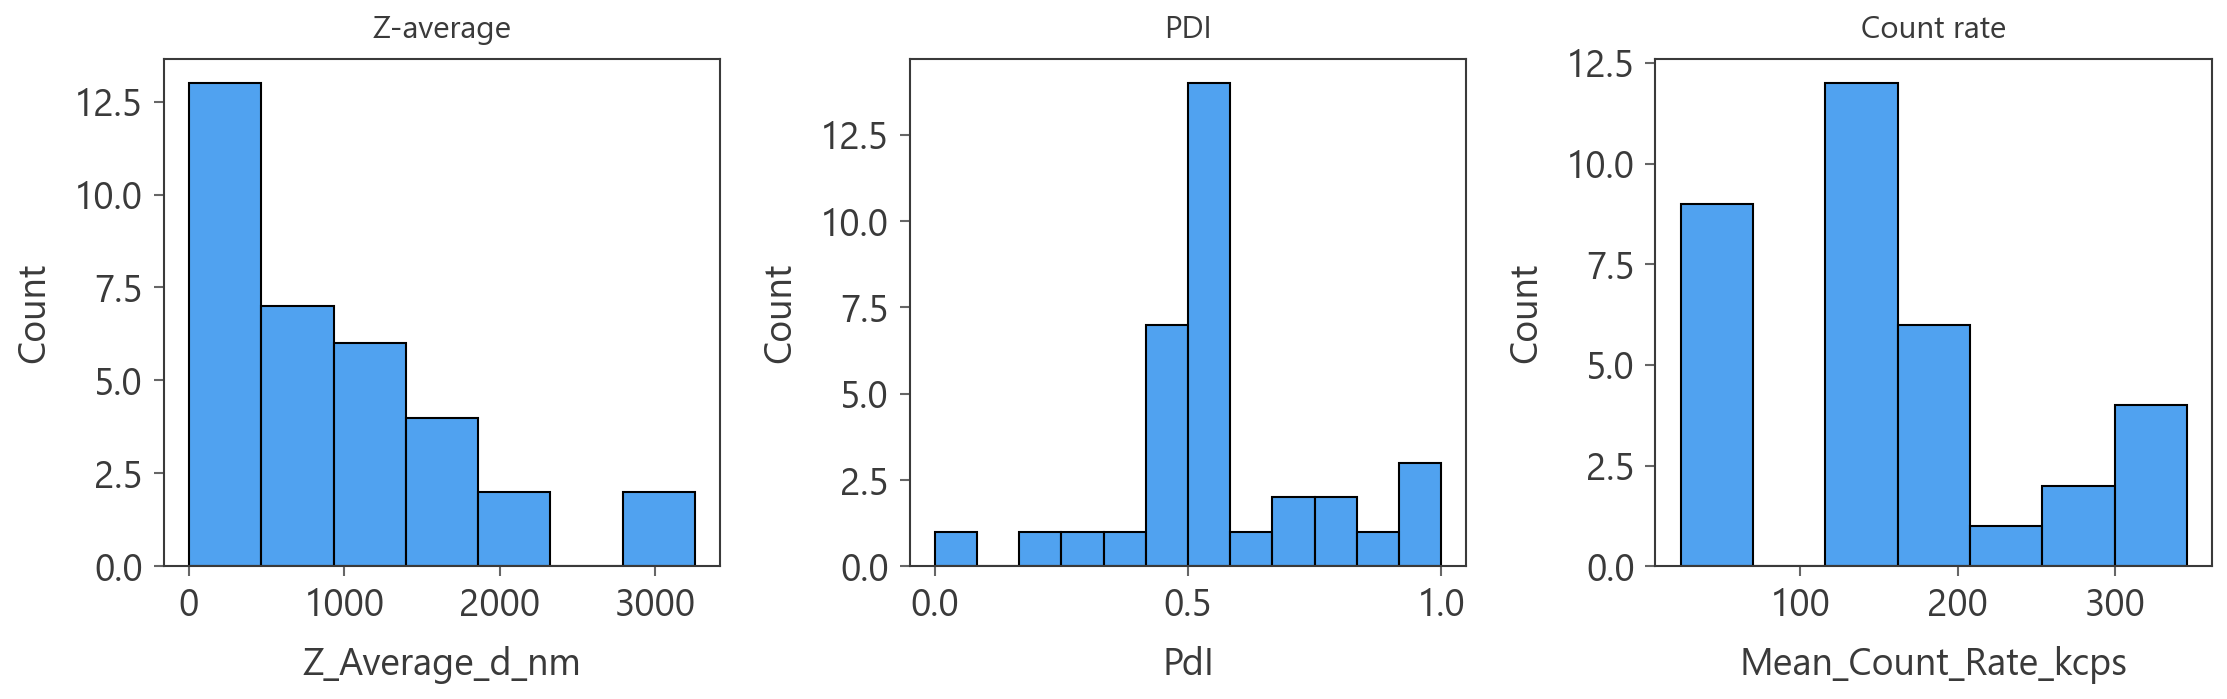

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df_dls_main["Z_Average_d_nm"], ax=axes[0])
axes[0].set_title("Z-average")

sns.histplot(df_dls_main["PdI"], ax=axes[1])
axes[1].set_title("PDI")

sns.histplot(df_dls_main["Mean_Count_Rate_kcps"], ax=axes[2])
axes[2].set_title("Count rate")

plt.tight_layout()

#### **Z-average**

- Distribuição muito espalhada (0 → ~3000 nm)
- Claramente não unimodal
- Forte cauda para valores altos

**Interpretação**:

Isso não é um sistema coloidal monodisperso

Você está vendo:
- agregados grandes
- possivelmente redes/transientes
- e/ou contribuição de partículas/proteínas no meio

**Ponto importante**:

Z-average aqui é dominado por espalhamento intenso de populações maiores

→ não representa “tamanho médio real”

#### **PDI**

- A maioria entre 0.4 – 0.7
- alguns valores → >0.8

**Interpretação**:

Sistema consistentemente polidisperso

Isso é esperado para:
- polímeros em solução
- interações polímero–proteína
- agregação dependente de concentração

**Tradução prática**:

Não usar PDI como critério de exclusão rígido — usar como **indicador de heterogeneidade**

#### **Count rate**

- Faixa razoável (~50–350 kcps)
- Sem valores absurdamente baixos (bom)
- Sem saturação clara

**Interpretação**:

- Sinal experimental válido
- Diferenças entre condições refletem:
    - concentração efetiva
    - agregação
    - contraste óptico

## Quality criteria

Key-parameters:

1. Count rate

- too low → few dispersion → noise
- too high → strong aggregation possible / saturation

2. Intercept
- < ~0.2 → bad signal

3. PDI
- 0.7 → highly polidispersed
- do not delete automaticaly, but flag

### Create quality flags

In [ ]:
df_qc = df_dls_main.copy()

df_qc["flag_low_count_rate"] = df_qc["Mean_Count_Rate_kcps"] < 50
df_qc["flag_low_intercept"]  = df_qc["Intercept"] < 0.2
df_qc["flag_high_pdi"]       = df_qc["PdI"] > 0.7

df_qc["flag_bad_signal"] = (
    df_qc["flag_low_count_rate"] |
    df_qc["flag_low_intercept"]
)

### Visualize flags

In [13]:
df_qc[[
    "Sample_Name",
    "Z_Average_d_nm",
    "PdI",
    "Mean_Count_Rate_kcps",
    "Intercept",
    "flag_low_count_rate",
    "flag_low_intercept",
    "flag_high_pdi"
]].sort_values("Mean_Count_Rate_kcps")

,Sample_Name,Z_Average_d_nm,PdI,Mean_Count_Rate_kcps,Intercept,flag_low_count_rate,flag_low_intercept,flag_high_pdi
3,milli_q-water 1,0.00,0.000,24.4,0.000,True,True,False
17,i_2S-20ug_mL 2,761.50,0.547,31.7,0.657,True,False,False
13,aMEM-Ctrl 1,3255.00,1.000,38.3,0.924,True,False,True
16,i_2S-20ug_mL 1,2994.00,1.000,40.1,1.050,True,False,True
14,aMEM-Ctrl 2,635.70,0.466,45.3,0.578,True,False,False
20,L_3S-35ug_mL 2,947.40,0.516,48.5,0.741,True,False,False
21,L_3S-35ug_mL 3,844.10,0.547,51.3,0.668,False,False,False
19,L_3S-35ug_mL 1,1408.00,0.829,53.0,0.806,False,False,True
15,aMEM-Ctrl 3,895.30,0.559,63.6,0.540,False,False,False
9,aMEM_10pct-Ctrl 3,23.77,0.487,135.7,0.877,False,False,False


## Analysis per condition

### How many replicates per condition

In [14]:
df_qc.groupby("sample_base").size()

sample_base
L_3S-1mg_mL        3
L_3S-35ug_mL       3
aMEM-Ctrl          3
aMEM_10pct-Ctrl    3
aMEM_10pct-L_3s    3
aMEM_10pct-i_2s    3
aMEM_10pct-k_1s    3
i_2S-1mg_mL        3
i_2S-20ug_mL       3
k_1s-100ug_mL      3
k_1s-1mg_mL        3
milli_q-water      1
dtype: int64

### Variation by replicates

In [15]:
replicate_stats = (
    df_qc
    .groupby("sample_base")
    .agg(
        n=("replicate", "count"),
        zavg_mean=("Z_Average_d_nm", "mean"),
        zavg_std=("Z_Average_d_nm", "std"),
        pdi_mean=("PdI", "mean"),
        count_rate_mean=("Mean_Count_Rate_kcps", "mean")
    )
    .reset_index()
)

replicate_stats.sort_values("zavg_std", ascending=False)

,sample_base,n,zavg_mean,zavg_std,pdi_mean,count_rate_mean
2,aMEM-Ctrl,3,1595.333333,1443.162542,0.675000,49.066667
8,i_2S-20ug_mL,3,1541.866667,1258.756094,0.654000,78.800000
0,L_3S-1mg_mL,3,1941.666667,321.025440,0.828667,148.700000
1,L_3S-35ug_mL,3,1066.500000,300.223933,0.630667,50.933333
9,k_1s-100ug_mL,3,1369.666667,265.673358,0.661000,289.133333
7,i_2S-1mg_mL,3,1002.733333,226.760762,0.592333,326.166667
10,k_1s-1mg_mL,3,1053.300000,96.206393,0.328000,205.600000
6,aMEM_10pct-k_1s,3,28.926667,1.020016,0.500333,143.866667
3,aMEM_10pct-Ctrl,3,24.023333,0.582866,0.474333,136.200000
5,aMEM_10pct-i_2s,3,28.240000,0.487545,0.508667,145.066667


## Filtering decision 

Recommended strategy:

- DON'T remove auto
- Create subsets:

In [16]:
df_good = df_qc[~df_qc["flag_bad_signal"]].copy()
df_all = df_qc.copy()

In [17]:
print("Total:", df_qc.shape)
print("Good:", df_good.shape)

Total: (34, 26)
Good: (28, 26)


## Replicates merging

In [18]:
df_agg = (
    df_good
    .groupby([
        "sample_base",
        "carrageenan",
        "concentration_label",
        "matrix"
    ], dropna=False)
    .agg(
        n_replicates=("replicate", "count"),
        zavg_mean=("Z_Average_d_nm", "mean"),
        zavg_std=("Z_Average_d_nm", "std"),
        pdi_mean=("PdI", "mean"),
        pdi_std=("PdI", "std"),
        count_rate_mean=("Mean_Count_Rate_kcps", "mean")
    )
    .reset_index()
)

df_agg

,sample_base,carrageenan,concentration_label,matrix,n_replicates,zavg_mean,zavg_std,pdi_mean,pdi_std,count_rate_mean
0,L_3S-1mg_mL,lambda,1 mg/mL,water,3,1941.666667,321.025440,0.828667,0.180056,148.700000
1,L_3S-35ug_mL,lambda,35 ug/mL,water,2,1126.050000,398.737514,0.688000,0.199404,52.150000
2,aMEM-Ctrl,NaN,NaN,medium,1,895.300000,NaN,0.559000,NaN,63.600000
3,aMEM_10pct-Ctrl,NaN,NaN,medium,3,24.023333,0.582866,0.474333,0.021939,136.200000
4,aMEM_10pct-L_3s,lambda,35 ug/mL,medium,3,35.366667,0.171561,0.555333,0.005508,168.100000
5,aMEM_10pct-i_2s,iota,20 ug/mL,medium,3,28.240000,0.487545,0.508667,0.008021,145.066667
6,aMEM_10pct-k_1s,kappa,100 ug/mL,medium,3,28.926667,1.020016,0.500333,0.027610,143.866667
7,i_2S-1mg_mL,iota,1 mg/mL,water,3,1002.733333,226.760762,0.592333,0.149132,326.166667
8,i_2S-20ug_mL,iota,20 ug/mL,water,1,870.100000,NaN,0.415000,NaN,164.600000
9,k_1s-100ug_mL,kappa,100 ug/mL,water,3,1369.666667,265.673358,0.661000,0.080517,289.133333


## Firsts visuals

### **Z-average** per condition

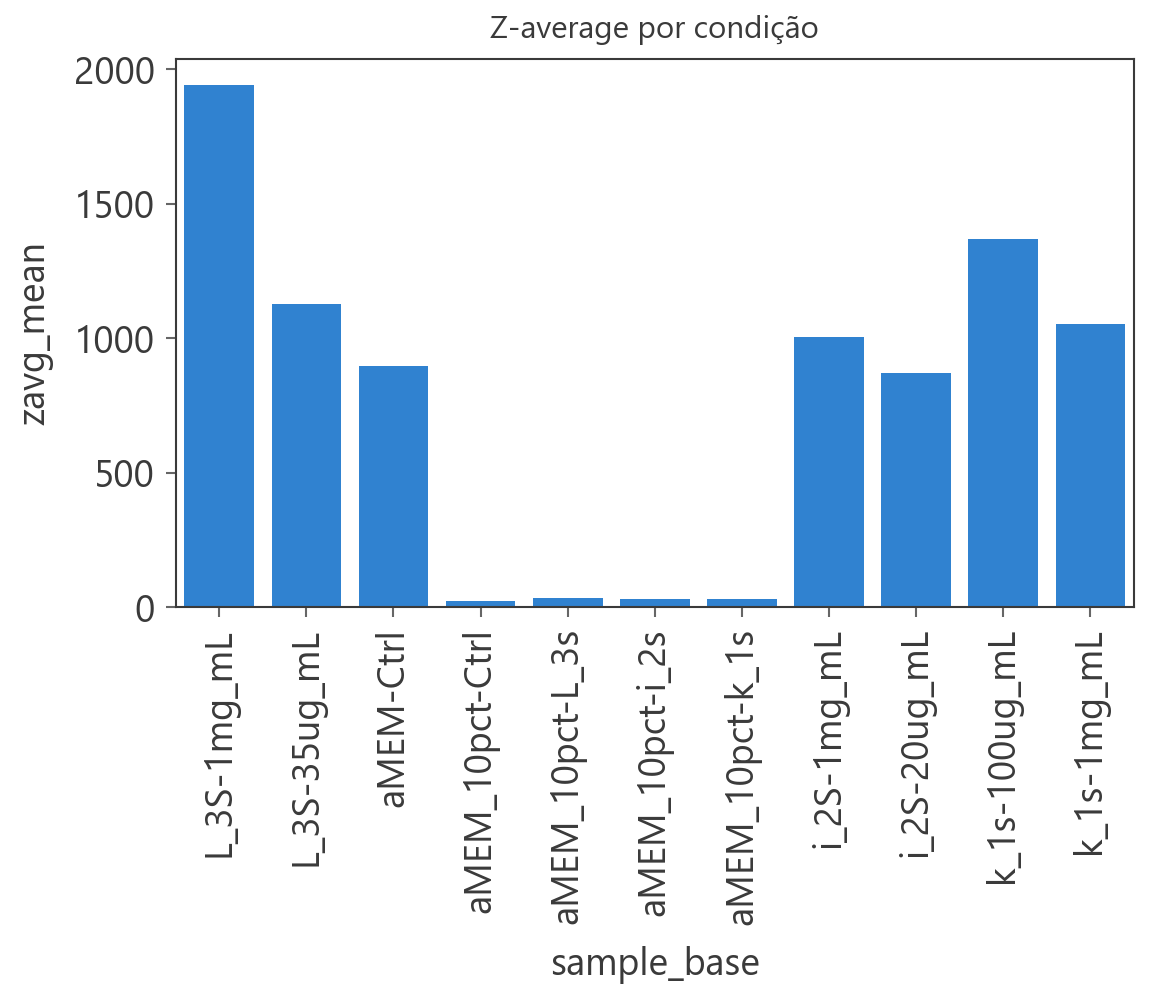

In [21]:
plt.figure(figsize=(8, 7))

sns.barplot(
    data=df_agg,
    x="sample_base",
    y="zavg_mean"
)

plt.xticks(rotation=90)
plt.title("Z-average por condição")
plt.tight_layout()

#### **Observação 1** | água vs meio

- Água → ~800–2000 nm
- Meio → ~30–50 nm (quase zero comparativamente)

Interpretação provável:

No meio (aMEM + proteínas):

- o sinal de DLS é dominado por:
    - proteínas (~5–20 nm)
    - complexos pequenos
- carragenana:
    - não forma grandes agregados detectáveis
    - ou é “mascarada” pelo background proteico

> Em meio biológico, o sistema colapsa para regime nanométrico pequeno ou perde contraste

#### **Observação 2** | carragenanas em água

λ (lambda)
- 35 ug/mL → ~1100 nm
- 1 mg/mL → ~1900 nm

> Forte aumento com concentração

κ (kappa)
- 100 ug/mL → ~1000 nm
- 1 mg/mL → ~1400 nm

> aumento moderado

ι (iota)
- 20 ug/mL → ~850 nm
- 1 mg/mL → ~1000 nm

> menor efeito de concentração

#### **Interpretação físico-química**

Ordem de tendência de agregação:

> λ > κ > ι

Possível explicação:

- λ: maior grau de sulfatação → maior carga → maior expansão + interação intermolecular
- κ: estrutura mais ordenada → agregação moderada
- ι: comportamento mais “solúvel”/menos agregante

> isso ainda precisa ser confirmado com distribuição (**Notebook 03**)

### **PDI** per condition

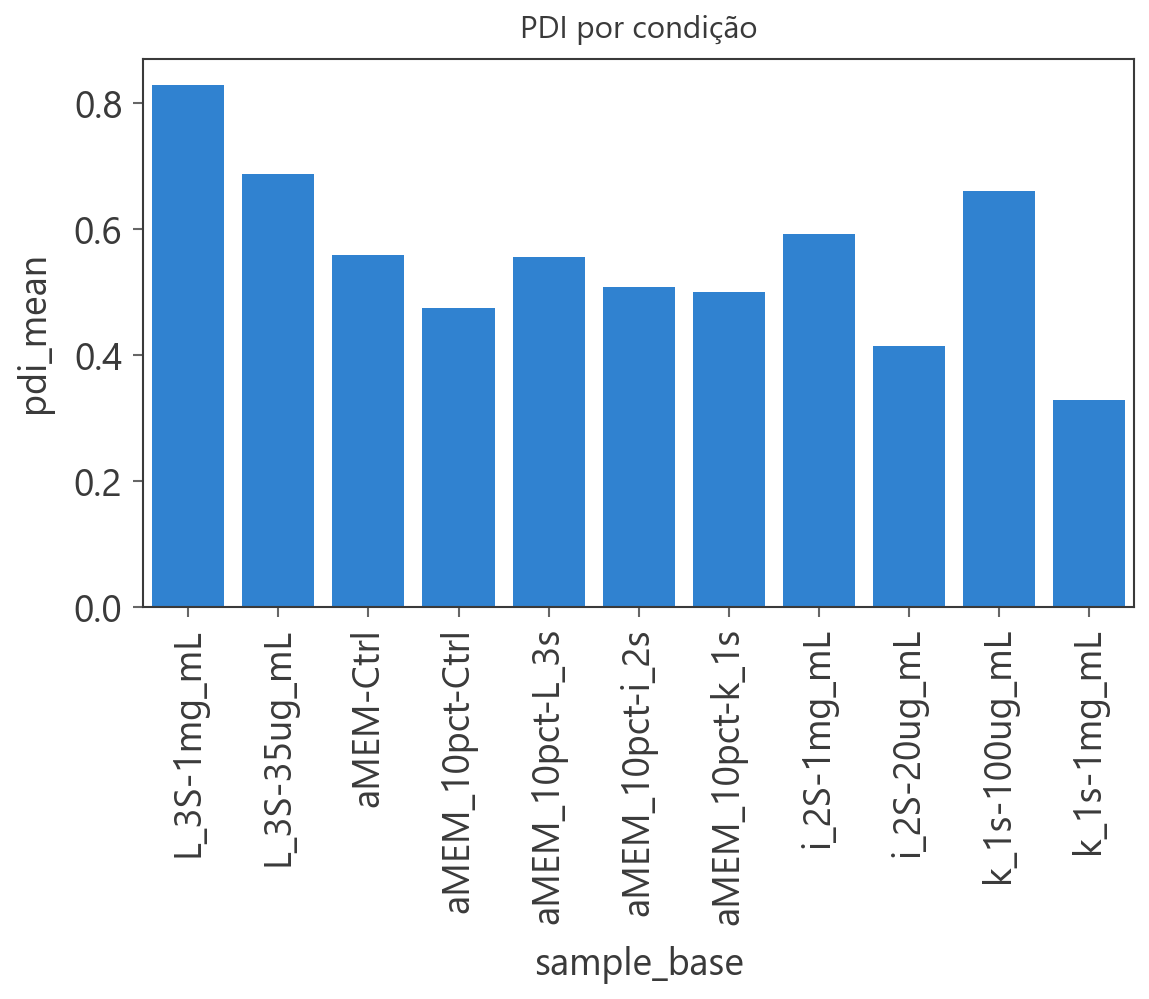

In [22]:
plt.figure(figsize=(8, 7))

sns.barplot(
    data=df_agg,
    x="sample_base",
    y="pdi_mean"
)

plt.xticks(rotation=90)
plt.title("PDI por condição")
plt.tight_layout()

- λ (1 mg/mL) → ~0.8 → altamente heterogêneo
- κ e ι → ~0.4–0.6


- λ → formação de populações múltiplas (clusters + cadeias)
- κ / ι → sistemas ainda polidispersos, mas menos extremos

### Comparision **water** *vs* **medium**

Text(0.5, 1.0, 'Z-average: água vs meio')

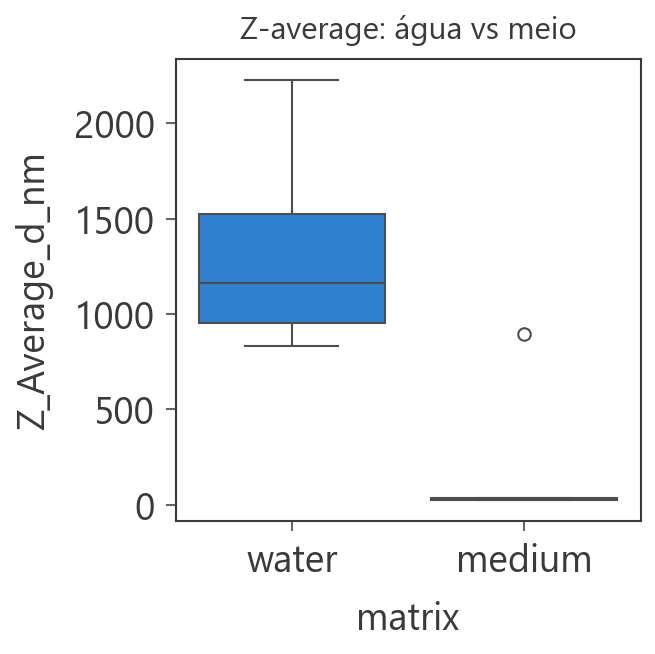

In [26]:
plt.figure(figsize=(4, 4))

sns.boxplot(
    data=df_good,
    x="matrix",
    y="Z_Average_d_nm"
)

plt.title("Z-average: água vs meio")

#### Filtering correction

In [28]:
df_cmp = df_good[df_good["carrageenan"].notna()]

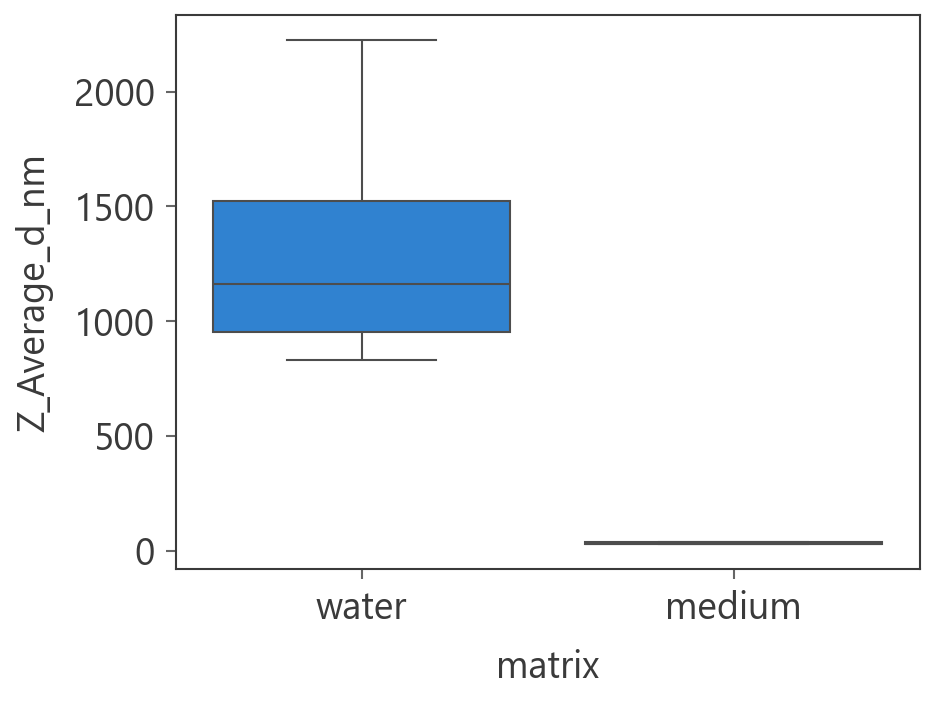

In [30]:
sns.boxplot(
    data=df_cmp,
    x="matrix",
    y="Z_Average_d_nm"
);

### Z-average per **carrageenan** and **matrix**

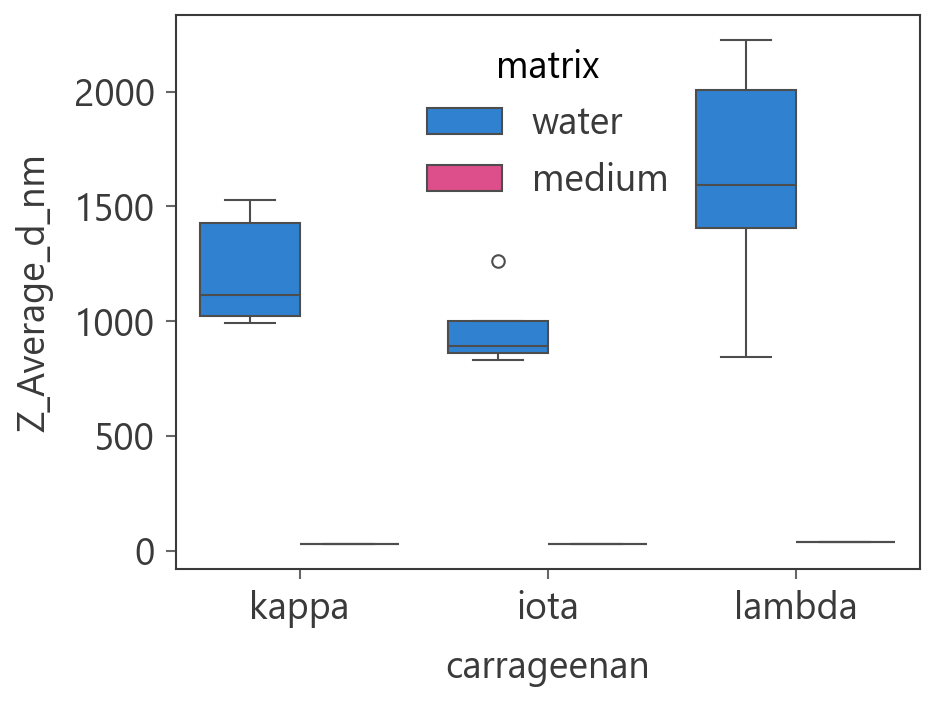

In [31]:
sns.boxplot(
    data=df_good[df_good["carrageenan"].notna()],
    x="carrageenan",
    y="Z_Average_d_nm",
    hue="matrix"
);

**Em água:**

- formação de estruturas grandes / agregados / redes
- comportamento dependente de:
    - tipo de carragenana
    - concentração

**Em meio:**

- sistema “colapsa” para ~tamanho de proteína
- carragenana:
    - não domina mais o espalhamento
    - pode estar:
        - dispersa
        - complexada
        - mascarada

> O meio biológico suprime ou mascara a organização coloidal das carragenanas observada em água.

### PDI per **carrageenan** and **matrix**

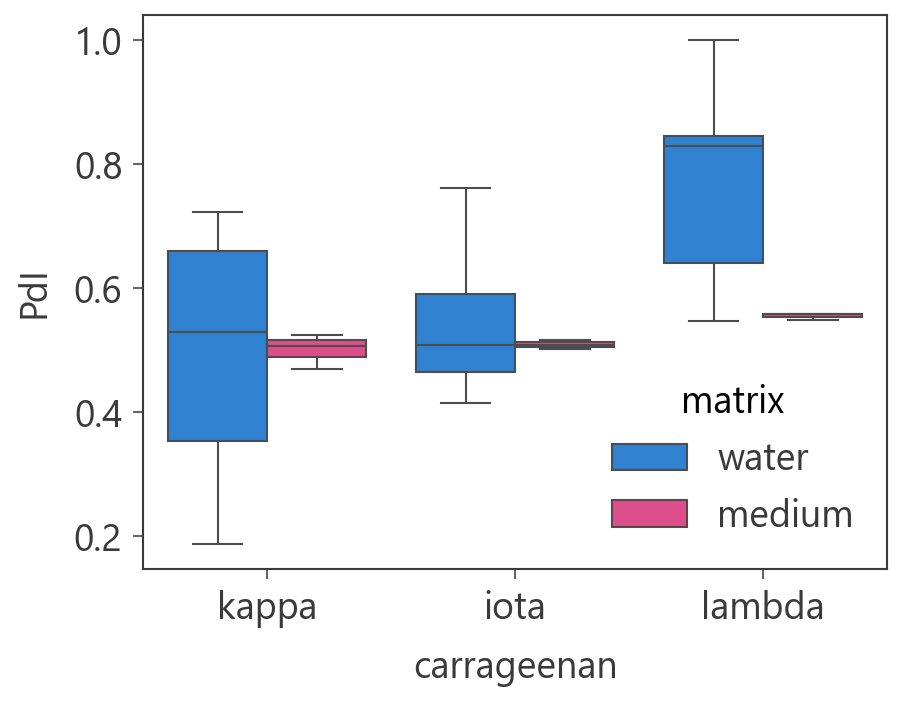

In [34]:
sns.boxplot(
    data=df_good[df_good["carrageenan"].notna()],
    x="carrageenan",
    y="PdI",
    hue="matrix"
);

### **Water** (plotted isolated)

In [41]:
df_water = df_good[
    (df_good["matrix"] == "water") &
    (df_good["carrageenan"].notna())
].copy()

df_medium = df_good[
    (df_good["matrix"] == "medium") &
    (df_good["carrageenan"].notna())
].copy()

df_control = df_good[df_good["carrageenan"].isna()].copy()

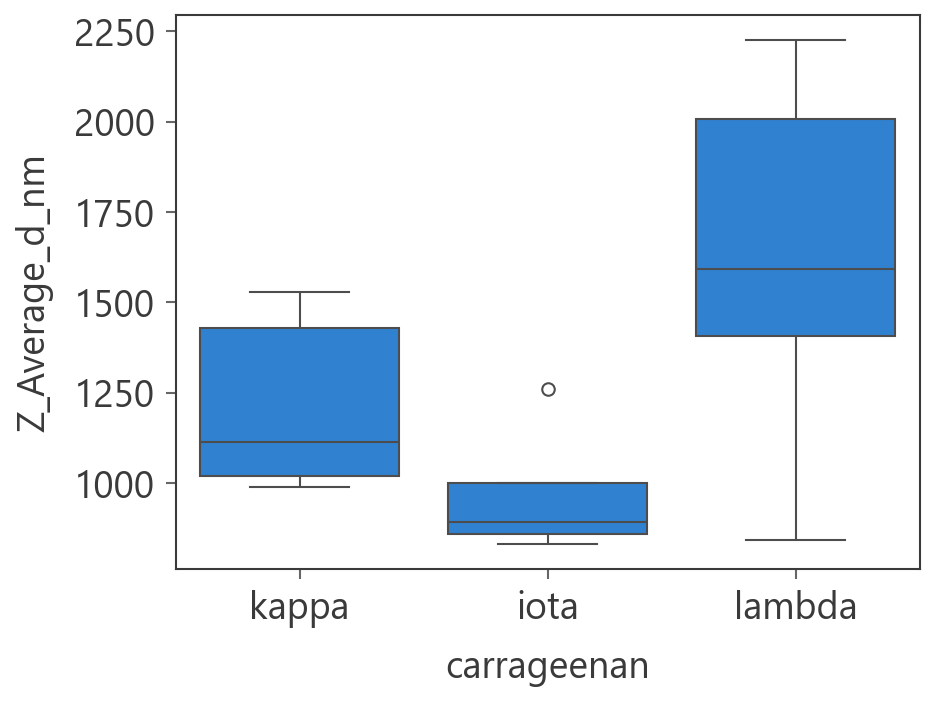

In [37]:
sns.boxplot(
    data=df_water,
    x="carrageenan",
    y="Z_Average_d_nm"
);

- λ > κ > ι em tamanho hidrodinâmico
- aumento com concentração (principalmente λ)

> Isso é comportamento típico de sistemas poliméricos carregados:
- λ (mais sulfatada) → maior expansão + interação intermolecular
- κ → intermediária
- ι → menor tendência a formar estruturas grandes

O que está se medindo aqui não são “partículas”, mas:
- agregados
- domínios
- possíveis redes transientes

### **Media** (plotted isolated)

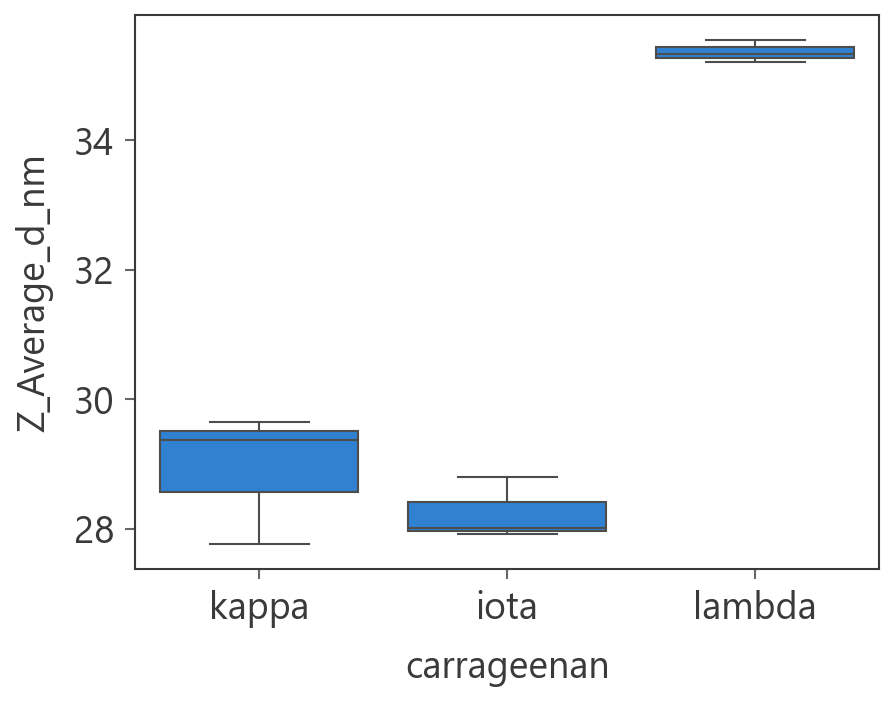

In [39]:
sns.boxplot(
    data=df_medium,
    x="carrageenan",
    y="Z_Average_d_nm"
);

- κ ~ 29 nm
- ι ~ 28 nm
- λ ~ 35 nm

> Isso é praticamente tamanho de proteína / agregados proteicos pequenos

No meio, as três carragenanas convergem para o mesmo regime físico.

Isso significa:
- o sistema deixa de ser “carragenana-dominado”
- passa a ser “meio-dominado”

### **Controls**  (plotted isolated)

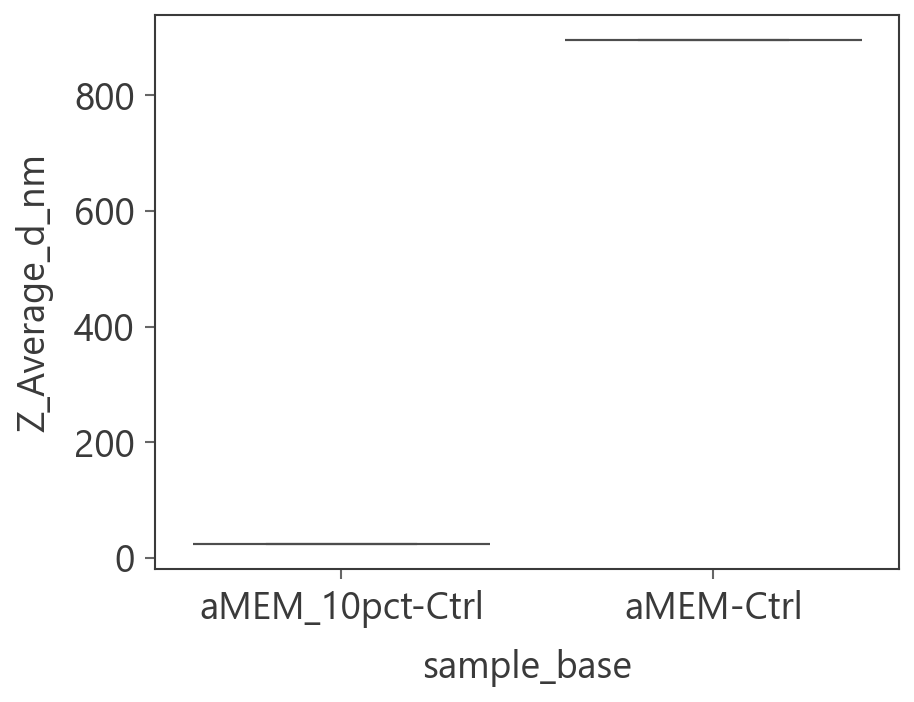

In [42]:
sns.boxplot(
    data=df_control,
    x="sample_base",
    y="Z_Average_d_nm"
);

- aMEM_10pct-Ctrl → ~30 nm
- aMEM-Ctrl → ~900 nm (!!)

Possível explicação:
- aMEM puro → formação de agregados grandes (sal + componentes?)
- aMEM + SFB → proteínas dominam → tamanho ~30 nm

> O SFB está redefinindo completamente o regime coloidal do sistema.

## **Final datasets saving**

In [ ]:
df_qc.to_csv(DATA_PROCESSED_DIR / "dls_qc.csv", index=False)
df_good.to_csv(DATA_PROCESSED_DIR / "dls_filtered.csv", index=False)
df_agg.to_csv(DATA_PROCESSED_DIR / "dls_aggregated.csv", index=False)

Datasets salvos


# Final considerations

## Overview

Dynamic Light Scattering (DLS) measurements were performed to investigate the hydrodynamic behavior of κ-, ι-, and λ-carrageenans under two distinct environments:

- **Aqueous systems (Milli-Q water)**
- **Biological-like medium (α-MEM ± serum components)**

Given the nature of the systems (polymer solutions and complex biological media), all size measurements are interpreted as **apparent hydrodynamic sizes**, not discrete particle diameters.

---

## 1. Behavior in Aqueous Systems

### 1.1 Hydrodynamic Size (Z-average)

All carrageenans exhibited large apparent hydrodynamic sizes in water, typically in the range of:

- ~800–2000 nm

A clear trend was observed:

> **λ > κ > ι**

Additionally, an increase in concentration led to an increase in apparent size, particularly pronounced for λ-carrageenan.

### Interpretation

This behavior suggests the formation of:

- polymer aggregates
- transient networks
- supramolecular structures

rather than isolated polymer chains.

The stronger effect observed for λ-carrageenan is consistent with its higher degree of sulfation, which may promote:

- increased chain expansion
- enhanced intermolecular interactions

---

### 1.2 Polydispersity (PDI)

All systems showed high PDI values:

- typically between **0.4 and 0.8**
- λ-carrageenan reaching values close to **1.0**

### Interpretation

These values indicate:

- highly polydisperse systems
- presence of multiple populations
- significant structural heterogeneity

Thus, the use of Z-average alone is insufficient to fully describe the system, and distribution-based analysis is required.

---

## 2. Behavior in Biological Medium

### 2.1 Hydrodynamic Size Collapse

In α-MEM-based media, all carrageenan systems exhibited a dramatic reduction in apparent size:

- ~28–35 nm for all carrageenans

Notably:

- No significant differences between κ, ι, and λ were observed

### Interpretation

This indicates a fundamental shift in the system:

> The DLS signal is no longer dominated by carrageenan structures.

Instead, the measurements likely reflect:

- serum proteins
- protein aggregates
- small complexes in the medium

Carrageenan either:

- does not form large detectable aggregates in this environment, or
- becomes masked by the dominant scattering contribution of proteins

---

### 2.2 Polydispersity in Medium

PDI values in the medium were:

- relatively consistent (~0.5–0.55)
- similar across all carrageenan types

### Interpretation

This suggests a more uniform (though still heterogeneous) system, likely governed by the intrinsic properties of the biological medium rather than the polymers.

---

## 3. Role of the Medium and Serum Components

Control samples revealed a critical effect:

- **α-MEM alone** showed large apparent sizes (~900 nm)
- **α-MEM + serum (10%)** showed small sizes (~30 nm)

### Interpretation

This suggests that:

- serum components (e.g., proteins) significantly alter the colloidal environment
- they may:
  - stabilize smaller structures
  - suppress aggregation
  - dominate scattering intensity

---

## 4. Comparative Interpretation

### Key Observation

> The structural organization observed in aqueous systems is not preserved in biological media.

This implies that:

- carrageenan behavior is highly environment-dependent
- conclusions based solely on aqueous measurements may not reflect biologically relevant conditions

---

## 5. Implications for Biological Systems

These findings suggest that:

- in vitro cellular interactions likely occur with carrageenan in a **non-aggregated or protein-associated state**
- the large-scale structures observed in water are unlikely to be directly involved in biological responses

This highlights the importance of:

- studying biomaterials in physiologically relevant environments
- considering polymer–protein interactions in interpretation

---

## 6. Limitations and Next Steps

- DLS results are intensity-weighted and biased toward larger scatterers
- high PDI values indicate that distribution-based analysis is required

### Next steps:

- analyze intensity distributions (multimodality, peak structure)
- evaluate autocorrelation functions
- assess signal quality and fitting behavior

---

## Final Remark

Overall, the dataset reveals a **strong matrix-dependent transition in carrageenan organization**, with a shift from large, heterogeneous aggregates in water to small, protein-dominated structures in biological media.

This transition is central to understanding the physicochemical behavior and potential biological activity of these systems.